# Pathway Functional Clustering (데이터 기반 theme 검증)

`gene_enrichment.ipynb`의 signature 시각화는 **수동 큐레이션 theme**(경로명 키워드 매칭)으로 묶는다.
본 노트북은 그와 **독립적으로**, FDR<0.05로 검증된 경로들을 **leading-edge 유전자 공유(기능적 유사도)**로
자동 군집하여, 수동 theme이 실제 데이터 구조와 일치하는지 교차검증한다.

**방법 (EnrichmentMap; Merico et al., PLoS ONE 2010):**
1. 경로쌍 유사도 = `0.5·Jaccard + 0.5·Overlap` (leading-edge 유전자 집합 기준)
2. 유사도 ≥ 임계값(기본 0.3)인 경로쌍을 edge로 연결한 그래프 구성
3. **Leiden** 커뮤니티 검출(가중치 기반)로 군집 → 군집 라벨은 경로명 토큰 빈도에서 자동 생성
4. 네트워크(노드=경로, 크기=|NES|, 색=군집) + 군집 요약표 출력

→ 수동 theme이 "사람이 정한 키워드"가 아니라 "경로들이 실제 공유하는 유전자"에서도 재현되면,
   수동 분류의 방법론적 정당성이 확보된다.

In [2]:
import sys, os, warnings, re
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
from pathlib import Path
from itertools import combinations
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import igraph as ig
import leidenalg as la

parent_dir = str(Path(os.getcwd()).parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from viz_style import apply_style
apply_style()

BASE_DIR = Path('.').resolve()
GSEA_DIR = BASE_DIR / 'GSEA'                 # gsea_result_{ph}.csv 위치
FIG_DIR  = GSEA_DIR / 'Figures' / 'functional_clusters'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ──────────────────────────────────────────────
SIM_THR    = 0.20   # edge 임계값 (combined coefficient)
RESOLUTION = 0.50   # Leiden resolution (↑ = 더 잘게 쪼갬)
UP, DN     = '#d62728', '#1f77b4'

print('GSEA_DIR:', GSEA_DIR)
print('available CSVs:', len(list(GSEA_DIR.glob('gsea_result_*.csv'))))

GSEA_DIR: /project/cfRNA_NormativeModeling/Modeling/GSEA
available CSVs: 22


## 핵심 함수

- `get_sig(ph, direction)` : FDR<0.05 경로 로드 (`up`/`down`/`both`)
- `emap_sim` : leading-edge 기반 combined 유사도
- `cluster_pathways` : 그래프 구성 + Leiden 군집
- `label_cluster` : 군집 자동 라벨 (토큰 빈도)
- `cluster_summary` : 군집 요약표 (크기·라벨·대표 경로·평균 NES) → CSV 저장

In [3]:
def get_sig(ph, direction='up'):
    """FDR<0.05 경로 로드. CSV는 이미 FDR<0.05만 저장되어 있음."""
    f = GSEA_DIR / f"gsea_result_{ph.replace('/', '_')}.csv"
    g = pd.read_csv(f)
    g['NES']   = pd.to_numeric(g['NES'], errors='coerce')
    g['clean'] = g['Term'].str.split('__').str[1].fillna(g['Term'])
    g = g[g['NES'].notna() & g['Lead_genes'].notna()].copy()
    if direction == 'up':   g = g[g['NES'] > 0]
    elif direction == 'down': g = g[g['NES'] < 0]
    return g.reset_index(drop=True)

def _lead_sets(df):
    return [set(str(s).split(';')) for s in df['Lead_genes']]

def emap_sim(a, b):
    """EnrichmentMap combined coefficient = 0.5*Jaccard + 0.5*Overlap."""
    inter = len(a & b)
    if inter == 0:
        return 0.0
    return 0.5 * (inter / len(a | b)) + 0.5 * (inter / min(len(a), len(b)))

def cluster_pathways(df, sim_thr=SIM_THR, resolution=RESOLUTION):
    """leading-edge 유사도 그래프 + Leiden 군집. returns (labels, edges, weights)."""
    sets = _lead_sets(df); n = len(df)
    edges, w = [], []
    for i, j in combinations(range(n), 2):
        s = emap_sim(sets[i], sets[j])
        if s >= sim_thr:
            edges.append((i, j)); w.append(s)
    G = ig.Graph(n=n, edges=edges)
    if w:
        G.es['weight'] = w
    part = la.find_partition(
        G, la.RBConfigurationVertexPartition,
        weights='weight' if w else None,
        resolution_parameter=resolution, seed=42)
    return np.array(part.membership), edges, w

_STOP = {'of','the','and','to','in','by','via','an','a','signaling','pathway','pathways',
         'process','regulation','positive','negative','response','complex','activity',
         'cell','protein','mediated','dependent','formation','involved','its','for','on'}
def label_cluster(terms, k=3):
    """군집 경로명에서 정보성 토큰 top-k → 자동 라벨."""
    toks = []
    for t in terms:
        for wd in re.split(r'[\s,\-/():]+', t.lower()):
            if (wd and wd not in _STOP and len(wd) > 2
                    and not wd.replace('.', '').isdigit() and not wd.startswith('hsa')):
                toks.append(wd)
    top = [w for w, _ in Counter(toks).most_common(k)]
    return ' / '.join(top) if top else '(misc)'

def cluster_summary(ph, direction='up', sim_thr=SIM_THR, resolution=RESOLUTION, save=True):
    df = get_sig(ph, direction)
    labels, edges, w = cluster_pathways(df, sim_thr, resolution)
    df['cluster'] = labels
    rows = []
    for c, sub in df.groupby('cluster'):
        rep = sub.loc[sub['NES'].abs().idxmax()]
        rows.append(dict(cluster=c, size=len(sub),
                         auto_label=label_cluster(list(sub['clean'])),
                         representative=rep['clean'], rep_NES=round(rep['NES'], 2),
                         mean_NES=round(sub['NES'].mean(), 2)))
    summ = (pd.DataFrame(rows).sort_values('size', ascending=False)
              .reset_index(drop=True))
    if save:
        fn = f"clusters_{ph.replace(' ', '_').replace('/', '_')}_{direction}.csv"
        summ.to_csv(FIG_DIR / fn, index=False)
    return df, summ

## 네트워크 시각화 (EnrichmentMap style)

In [4]:
import matplotlib.cm as cm

def plot_emap(ph, direction='up', sim_thr=SIM_THR, resolution=RESOLUTION,
              label_min=3, save=True):
    """노드=경로(크기 |NES|), edge=leading-edge 유사도, 색=군집.
    2개 이상 묶인 모듈만 채색·라벨, singleton은 회색·축소로 배경 처리."""
    df, summ = cluster_summary(ph, direction, sim_thr, resolution, save=save)
    labels, edges, w = cluster_pathways(df, sim_thr, resolution)
    n = len(df)

    G = nx.Graph(); G.add_nodes_from(range(n))
    for (i, j), ww in zip(edges, w):
        G.add_edge(i, j, weight=ww)
    pos = nx.spring_layout(G, weight='weight', seed=42,
                           k=2.5/np.sqrt(max(n, 2)), iterations=200)

    sizes = pd.Series(labels).value_counts()
    multi = list(sizes[sizes >= 2].index)            # 모듈(2+ 경로)만 채색
    palette = (cm.tab20.colors * (len(multi)//20 + 1))[:len(multi)]
    cl2col = {c: palette[i] for i, c in enumerate(sorted(multi))}

    nes = np.abs(df['NES'].values)
    node_col, node_sz = [], []
    for k_, c in enumerate(labels):
        if c in cl2col:
            node_col.append(cl2col[c]); node_sz.append(np.clip(nes[k_]*70, 60, 420))
        else:
            node_col.append('#dcdcdc'); node_sz.append(np.clip(nes[k_]*40, 25, 140))
    node_ec = [UP if v > 0 else DN for v in df['NES'].values]

    side = float(np.clip(np.sqrt(n) * 0.95, 9, 22))  # 정사각·상한 → 과도한 종횡비 방지
    fig, ax = plt.subplots(figsize=(side, side))
    for (i, j), ww in zip(edges, w):
        ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
                color='#aaaaaa', lw=ww*2.5, alpha=0.4, zorder=1)
    xs = [pos[i][0] for i in range(n)]; ys = [pos[i][1] for i in range(n)]
    ax.scatter(xs, ys, s=node_sz, c=node_col, edgecolors=node_ec,
               linewidths=1.2, zorder=3, alpha=0.95)

    for c in sorted(cl2col):
        idx = np.where(labels == c)[0]
        if len(idx) < label_min:
            continue
        cx = np.mean([pos[i][0] for i in idx]); cy = np.mean([pos[i][1] for i in idx])
        lab = label_cluster(list(df.loc[idx, 'clean']))
        ax.text(cx, cy, f"{lab}\n(n={len(idx)})", ha='center', va='center', zorder=5,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=cl2col[c], alpha=0.9))

    n_mod = len(multi); n_single = int((sizes == 1).sum())
    ax.set_title(f'Functional clustering (leading-edge) — {ph} [{direction}]\n'
                 f'{n} pathways · {n_mod} modules (2+) · {n_single} singletons')
    ax.axis('off')
    plt.tight_layout()
    if save:
        fn = f"emap_{ph.replace(' ', '_').replace('/', '_')}_{direction}.png"
        plt.savefig(FIG_DIR / fn, bbox_inches='tight')
    plt.show()
    return summ

## 실행 — 심혈관 (CAD: HF 진행 vs 비진행)

수동 THEMES(`gene_enrichment.ipynb`)와 비교하라.
CAD_HF+의 상향 신호가 데이터만으로도 **FGFR1 / 응고 / 콜라겐 / 칼슘 / glycosaminoglycan** 군집으로 분리되면,
수동 theme이 데이터 구조와 일치함을 의미한다.

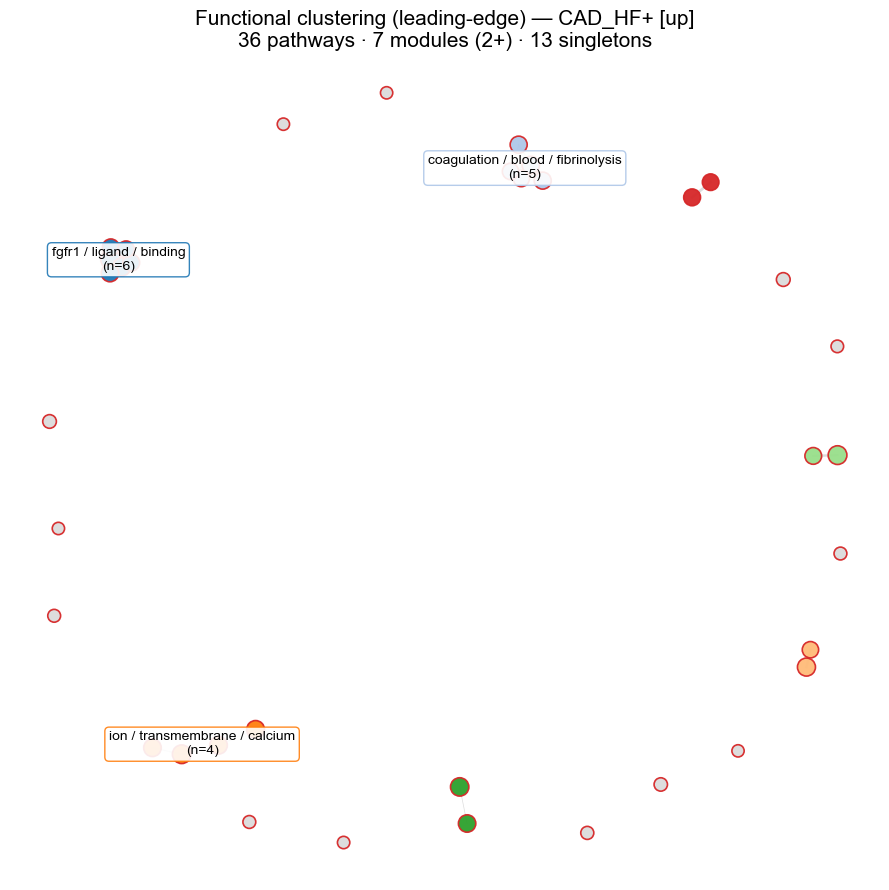

,cluster,size,auto_label,representative,rep_NES,mean_NES
0,0,6,fgfr1 / ligand / binding,FGFR1 Ligand Binding And Activation R-HSA-190242,2.82,2.28
1,1,5,coagulation / blood / fibrinolysis,Positive Regulation Of Blood Coagulation (GO:0...,2.26,2.11
2,2,4,ion / transmembrane / calcium,Calcium Ion Import Across Plasma Membrane (GO:...,2.57,2.37
3,3,2,receptor / type / tyrosine,Receptor-type Tyrosine-Protein Phosphatases R-...,2.41,2.19
4,4,2,coupled / receptor / cyclic,"G Protein-Coupled Receptor Signaling Pathway, ...",2.50,2.37
5,5,2,semaphorin / plexin / neuron,Semaphorin-Plexin Signaling Pathway Involved I...,2.60,2.34
6,6,2,glycosaminoglycan / metabolic / aminoglycan,Glycosaminoglycan Metabolic Process (GO:0030203),2.10,2.07
7,7,1,collagen / chain / trimerization,Collagen Chain Trimerization R-HSA-8948216,2.45,2.45
8,8,1,adhesion / calcium / plasma,Calcium-Dependent Cell-Cell Adhesion Via Plasm...,2.42,2.42
9,9,1,nicotine / addiction,Nicotine addiction,2.32,2.32


In [5]:
summ = plot_emap('CAD_HF+', 'up')
display(summ.head(12))

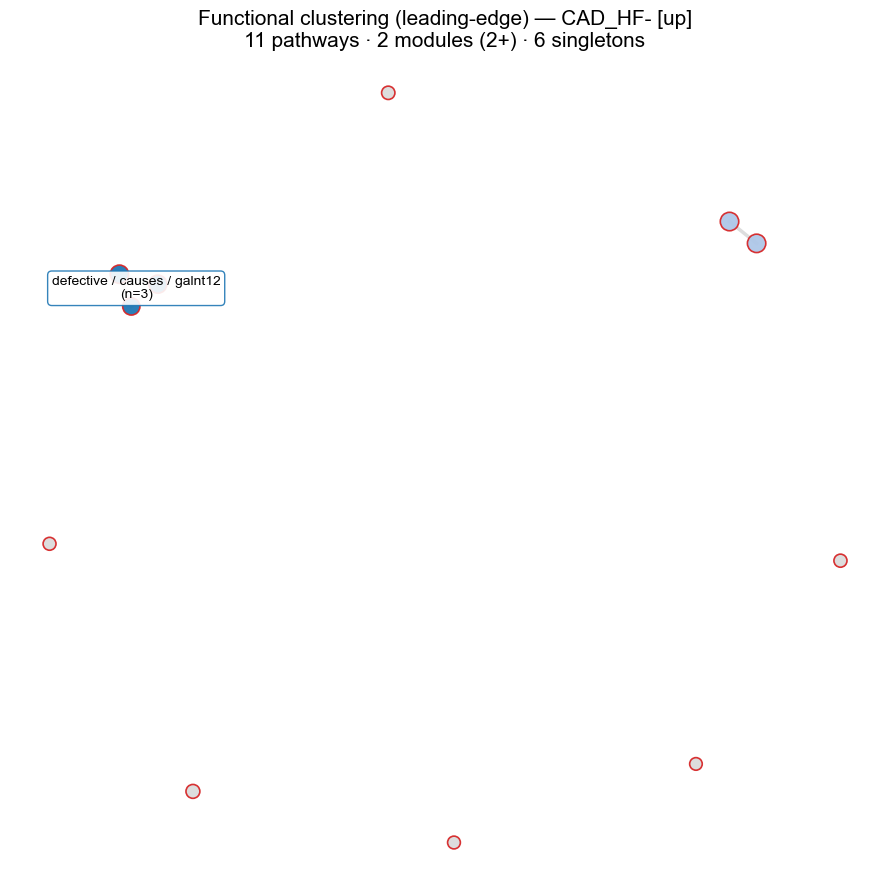

,cluster,size,auto_label,representative,rep_NES,mean_NES
0,0,3,defective / causes / galnt12,Defective GALNT12 Causes CRCS1 R-HSA-5083636,2.49,2.37
1,1,2,sensory / perception / pain,Regulation Of Sensory Perception (GO:0051931),2.52,2.51
2,2,1,beta / defensins,Beta Defensins R-HSA-1461957,2.50,2.50
3,3,1,nucleotide / like / purinergic,Nucleotide-like (Purinergic) Receptors R-HSA-4...,2.30,2.30
4,4,1,gag / synthesis / requires,GAG Synthesis Requires Tetrasaccharide Linker ...,2.22,2.22
5,5,1,fibrinolysis,Negative Regulation Of Fibrinolysis (GO:0051918),2.16,2.16
6,6,1,glycosaminoglycan / metabolic,Glycosaminoglycan Metabolic Process (GO:0030203),2.12,2.12
7,7,1,coagulation,Regulation Of Coagulation (GO:0050818),2.06,2.06


In [6]:
summ = plot_emap('CAD_HF-', 'up')
display(summ.head(12))

## 실행 — 다른 예시 (대규모 경로 집합)

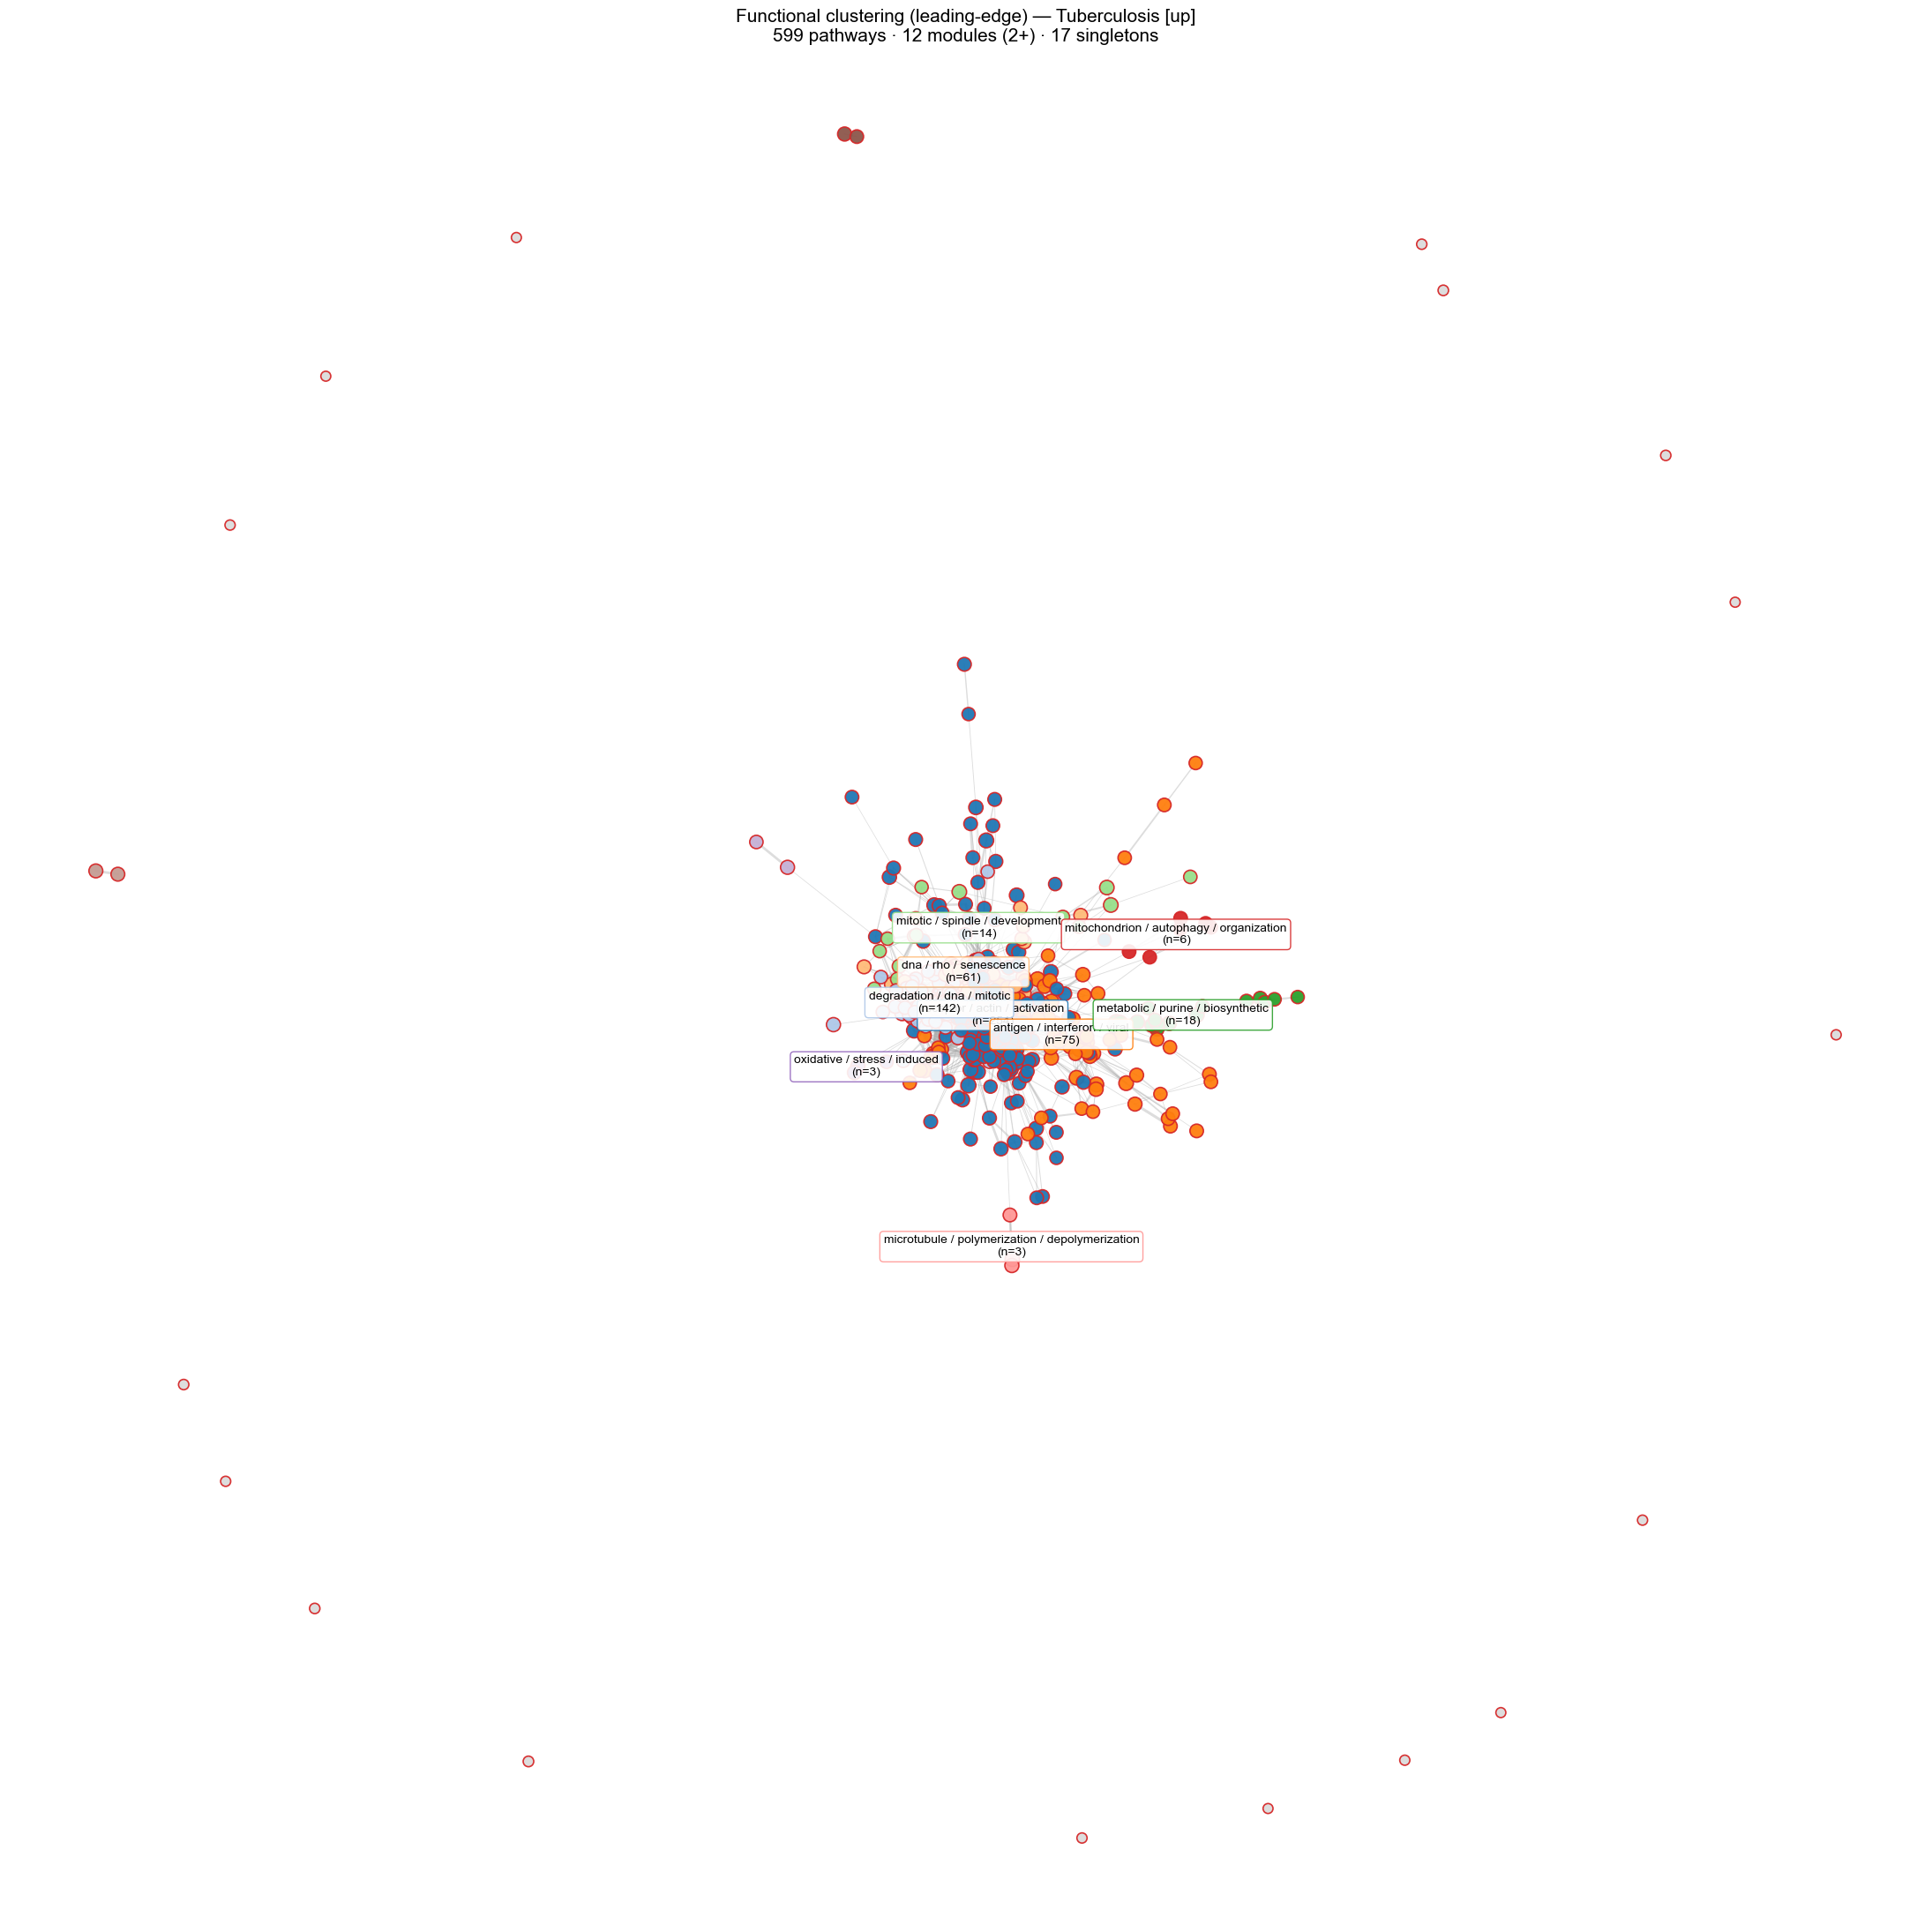

,cluster,size,auto_label,representative,rep_NES,mean_NES
0,0,254,receptor / actin / activation,Regulation Of Actin Dynamics For Phagocytic Cu...,2.42,1.83
1,1,142,degradation / dna / mitotic,RUNX1 Regulates Transcription Of Genes Involve...,2.27,1.82
2,2,75,antigen / interferon / viral,Interferon Alpha/Beta Signaling R-HSA-909733,2.47,1.83
3,3,61,dna / rho / senescence,Neutrophil extracellular trap formation,2.52,1.88
4,4,18,metabolic / purine / biosynthetic,Glycolytic Process (GO:0006096),2.27,1.85
5,5,14,mitotic / spindle / development,Erythrocyte Development (GO:0048821),2.00,1.76
6,6,6,mitochondrion / autophagy / organization,Regulation Of Mitochondrion Organization (GO:0...,1.74,1.72
7,7,3,microtubule / polymerization / depolymerization,Positive Regulation Of Microtubule Polymerizat...,1.98,1.87
8,8,3,oxidative / stress / induced,Negative Regulation Of Oxidative Stress-Induce...,1.88,1.80
9,9,2,integrin,Regulation Of Integrin-Mediated Signaling Path...,1.86,1.78


In [7]:
summ = plot_emap('Tuberculosis', 'up')
display(summ.head(12))

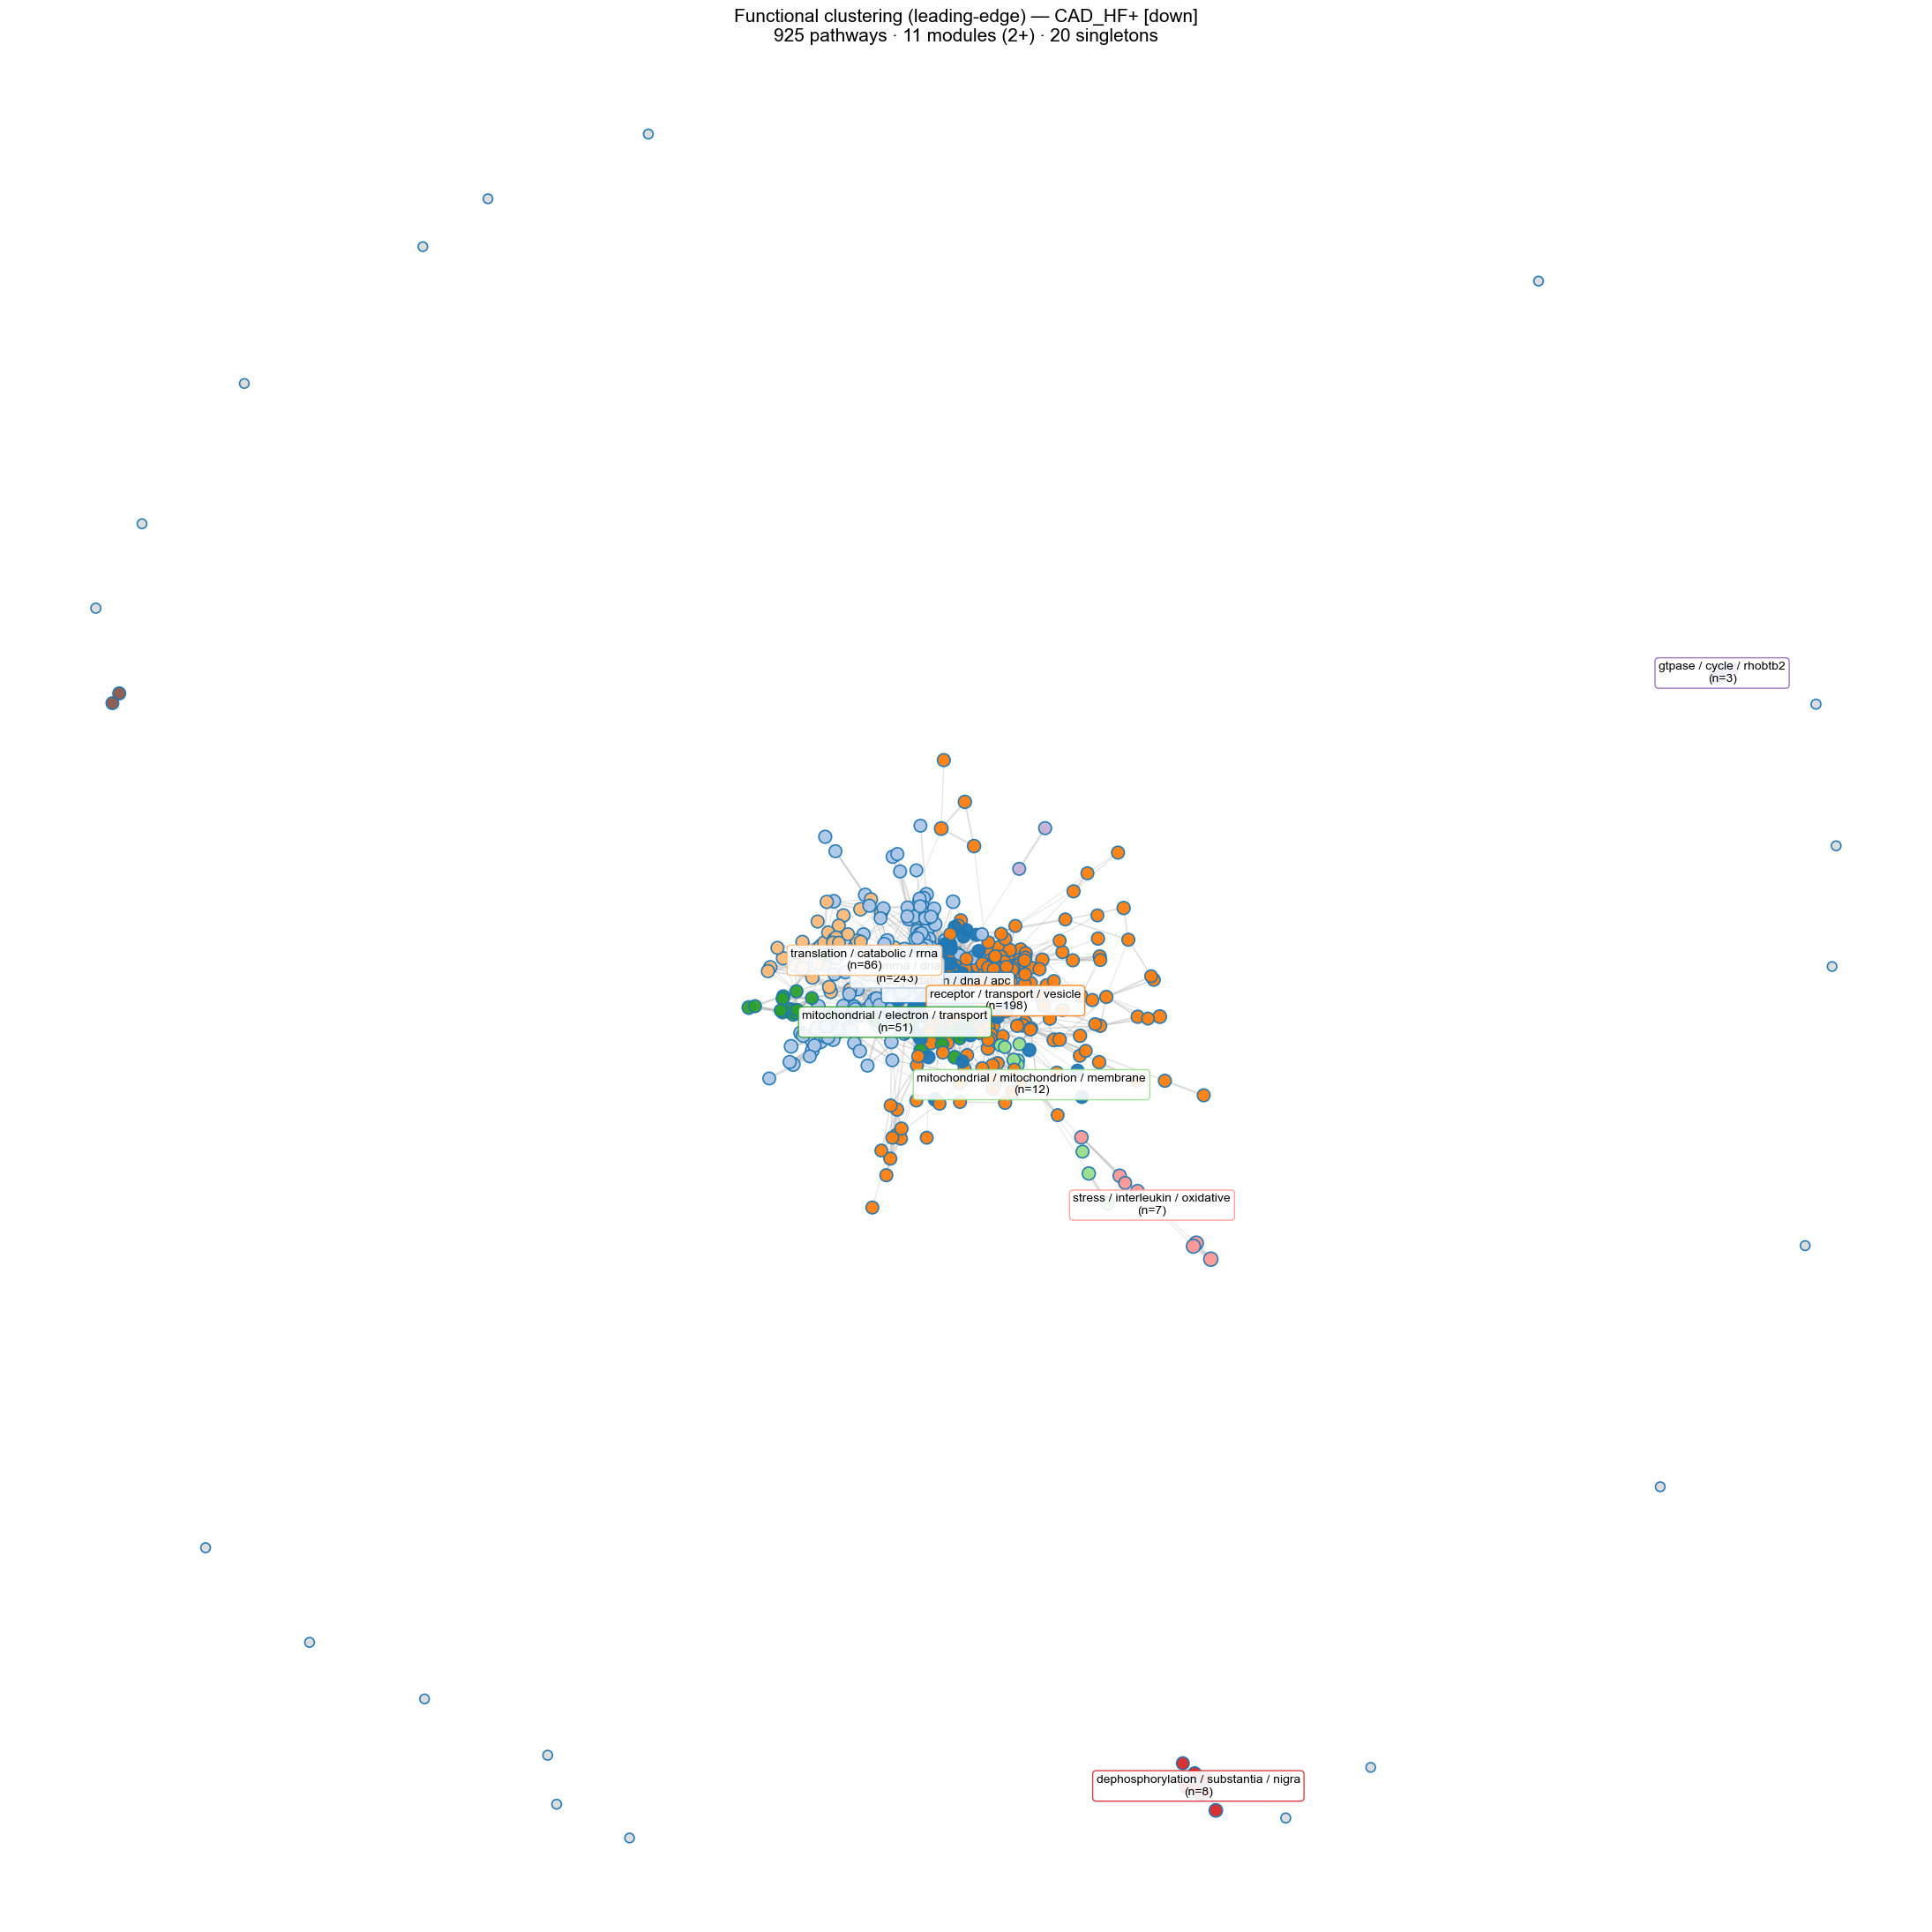

,cluster,size,auto_label,representative,rep_NES,mean_NES
0,0,293,degradation / dna / apc,Regulation Of Expression Of SLITs And ROBOs R-...,-2.07,-1.66
1,1,243,rna / mrna / dna,PRC2 Methylates Histones And DNA R-HSA-212300,-1.88,-1.64
2,2,198,receptor / transport / vesicle,Phosphatidylinositol-3-Phosphate Biosynthetic ...,-1.80,-1.57
3,3,86,translation / catabolic / rrna,Eukaryotic Translation Elongation R-HSA-156842,-2.28,-1.82
4,4,51,mitochondrial / electron / transport,ATP Biosynthetic Process (GO:0006754),-1.99,-1.65
5,5,12,mitochondrial / mitochondrion / membrane,Establishment Of Protein Localization To Mitoc...,-1.63,-1.57
6,6,8,dephosphorylation / substantia / nigra,Substantia Nigra Development (GO:0021762),-1.69,-1.56
7,7,7,stress / interleukin / oxidative,Gene And Protein Expression By JAK-STAT Signal...,-1.88,-1.72
8,8,3,gtpase / cycle / rhobtb2,RHOBTB2 GTPase Cycle R-HSA-9013418,-1.75,-1.70
9,9,2,intracellular / transport / establishment,Positive Regulation Of Intracellular Protein T...,-1.53,-1.53


In [8]:
summ = plot_emap('CAD_HF+', 'down')
display(summ.head(12))

## 해석 가이드

- **노드 테두리**: 빨강=NES>0(상향), 파랑=NES<0(하향). 노드 크기 ∝ |NES|.
- **edge**: leading-edge 유전자 공유 유사도(≥`SIM_THR`). 굵을수록 공유 유전자 많음.
- **군집 라벨**: 경로명 토큰 빈도 자동 생성(사람 개입 없음). `clusters_{ph}_{dir}.csv`에 전체 표 저장.
- **수동 theme과의 일치**: 자동 라벨이 `gene_enrichment.ipynb`의 수동 theme과 의미적으로 겹치면
  → "수동 분류 = 데이터 유도 구조" 라는 방어 논리 성립.
- **singleton(고립 노드)**: leading-edge를 공유하지 않는 독립 경로. `SIM_THR`을 낮추거나
  `RESOLUTION`을 낮추면 더 크게 묶인다(파라미터 민감도는 별도 점검 권장).